# fe_03. Anti data-leakage cu .shift(1)

**Pregatire SCSS 2026 - Diana Nenu**

**Acesta este notebook-ul cel mai important al seriei.**

Demonstram concret, pe cod si numere, ca implementarea naiva a rolling features introduce **data leakage** - feature-ul foloseste valoarea pe care vrem sa o prezicem - ceea ce face modelul sa para excelent in evaluare dar inutil in productie.

**Solutie**: o singura adaugare `.shift(1)` in pipeline.

**Obiective:**
1. Construim date sintetice tip time series energetic
2. Calculam rolling mean in doua moduri (FARA si CU shift)
3. Antrenam un model XGBoost pe fiecare varianta
4. Vedem ca varianta fara shift are R² fals enorm, dar e inutilizabila
5. Discutie: cum prinde acest bug auditarea

## 3.1 Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
np.random.seed(42)

## 3.2 Date sintetice tip pret energetic

Generez 1000 ore (~40 zile) de pret cu sezonalitate zilnica si zgomot.

In [2]:
n = 1000
rng = np.random.default_rng(42)
t = np.arange(n)
pret = (50 + 8 * np.cos(2 * np.pi * (t % 24 - 19) / 24)
        + np.cumsum(rng.normal(0, 0.15, n)))
df = pd.DataFrame({'pret': pret})
df.head()

,pret
0,52.116260
1,49.889710
2,47.931725
3,46.143362
4,44.193853


## 3.3 Cele doua variante de rolling mean

Construiesc **acelasi feature** in doua moduri:
- **`roll_mean_gresit`**: `df['pret'].rolling(3).mean()` - implementarea naiva
- **`roll_mean_corect`**: `df['pret'].shift(1).rolling(3).mean()` - implementarea cinstita

In [3]:
# IMPLEMENTARE GRESITA: fara shift
df['roll_mean_gresit'] = df['pret'].rolling(3).mean()

# IMPLEMENTARE CORECTA: cu shift(1) inainte de rolling
df['roll_mean_corect'] = df['pret'].shift(1).rolling(3).mean()

# Verific manual ce contine fiecare la ora t=5
print('La ora t=5:')
print(f'  pret[t=5]             = {df.loc[5, "pret"]:.3f}')
print(f'  pret[t=3,4,5]         = {df["pret"].iloc[3:6].values}')
print(f'  pret[t=2,3,4]         = {df["pret"].iloc[2:5].values}')
print(f'  roll_mean_gresit[t=5] = {df.loc[5, "roll_mean_gresit"]:.3f}  '
      f'(media t=3,4,5 - INCLUDE t=5!)')
print(f'  roll_mean_corect[t=5] = {df.loc[5, "roll_mean_corect"]:.3f}  '
      f'(media t=2,3,4 - DOAR trecutul)')

La ora t=5:
  pret[t=5]             = 42.727
  pret[t=3,4,5]         = [46.14336233 44.19385281 42.7271769 ]
  pret[t=2,3,4]         = [47.93172526 46.14336233 44.19385281]
  roll_mean_gresit[t=5] = 44.355  (media t=3,4,5 - INCLUDE t=5!)
  roll_mean_corect[t=5] = 46.090  (media t=2,3,4 - DOAR trecutul)


**Aici este capcana.** `roll_mean_gresit` la momentul t **include** valoarea de la t in medie. Cand modelul foloseste acest feature ca predictor pentru pret la momentul t, **vede deja raspunsul** (in proportie de 1/3, dar e suficient).

**`roll_mean_corect` cu shift(1)** foloseste valorile de la t-3, t-2, t-1 - DOAR trecutul. E un feature cinstit.

## 3.4 Antrenez 2 modele XGBoost si compar

Antrenez doua modele cu structura identica - difera doar feature-ul rolling. Folosesc XGBoost cu parametri default.

In [4]:
# Eliminam NaN-urile de la inceput
df_clean = df.dropna().reset_index(drop=True)

# Model 1: cu feature-ul GRESIT (cu leakage)
X_gresit = df_clean[['roll_mean_gresit']].values
y = df_clean['pret'].values

X_tr, X_te, y_tr, y_te = train_test_split(X_gresit, y, test_size=0.3, random_state=42)
m1 = XGBRegressor(n_estimators=50, max_depth=4, n_jobs=1, verbosity=0)
m1.fit(X_tr, y_tr)
y_pred1 = m1.predict(X_te)
r2_gresit = r2_score(y_te, y_pred1)
mae_gresit = mean_absolute_error(y_te, y_pred1)

# Model 2: cu feature-ul CORECT (cu shift)
X_corect = df_clean[['roll_mean_corect']].values
X_tr, X_te, y_tr, y_te = train_test_split(X_corect, y, test_size=0.3, random_state=42)
m2 = XGBRegressor(n_estimators=50, max_depth=4, n_jobs=1, verbosity=0)
m2.fit(X_tr, y_tr)
y_pred2 = m2.predict(X_te)
r2_corect = r2_score(y_te, y_pred2)
mae_corect = mean_absolute_error(y_te, y_pred2)

print(f'{"VARIANTA":<25}{"R^2":<10}{"MAE":<10}{"VERDICT"}')
print(f'{"-"*60}')
print(f'{"GRESIT (fara shift)":<25}{r2_gresit:<10.4f}{mae_gresit:<10.4f}DATA LEAKAGE - R^2 fals')
print(f'{"CORECT (cu shift(1))":<25}{r2_corect:<10.4f}{mae_corect:<10.4f}Model valid in productie')

VARIANTA                 R^2       MAE       VERDICT
------------------------------------------------------------
GRESIT (fara shift)      0.9330    1.3369    DATA LEAKAGE - R^2 fals
CORECT (cu shift(1))     0.7617    2.5434    Model valid in productie


## 3.5 De ce e atat de inselatoare prima varianta?

Modelul cu leakage are R² aparent foarte bun, dar este complet INUTIL in productie. Iata de ce:

In productie, la momentul t vrem sa prezicem pretul. Dar **nu cunoastem inca** pretul la t - exact asta e ce vrem sa aflam.

Cu `roll_mean_gresit`, calculul cere `pret[t-2], pret[t-1], pret[t]` - dar `pret[t]` este necunoscut. **Feature-ul nu poate fi calculat la momentul predictiei.** Modelul antrenat pe el este matematic corect, dar **operational inutil**.

Cu `roll_mean_corect` (`shift(1)` apoi rolling), calculul cere `pret[t-3], pret[t-2], pret[t-1]` - toate disponibile la momentul t. **Feature-ul poate fi calculat real-time.**

## 3.6 Vizualizare comparativa

Trasez ambele feature-uri impreuna cu pretul real.

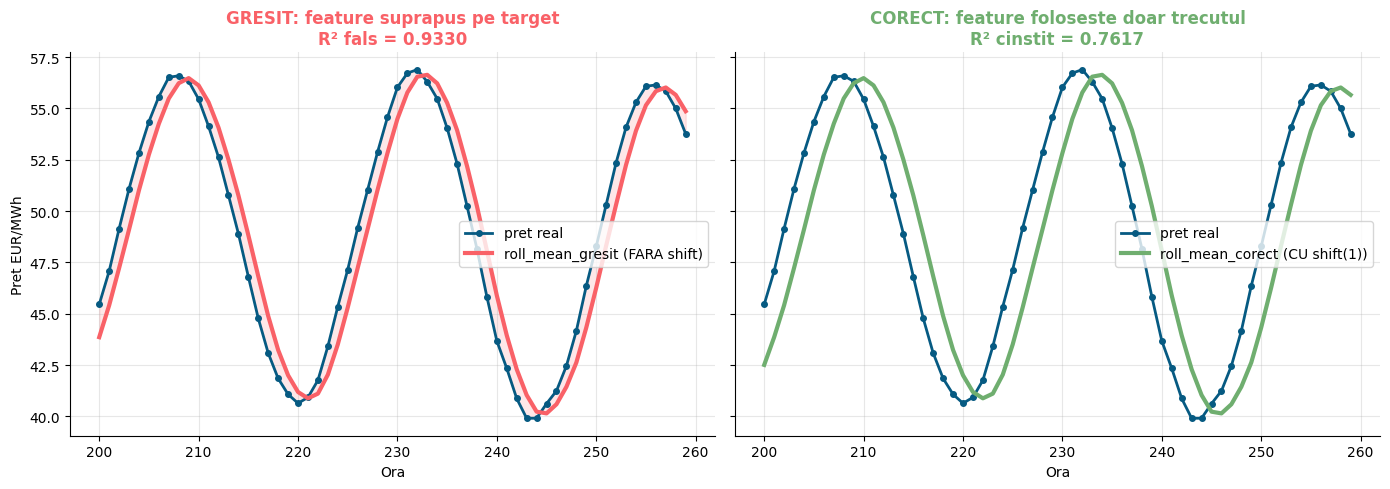

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
subset = df_clean.iloc[200:260]

# Stanga - feature-ul GRESIT (urmareste prea bine pretul)
ax = axes[0]
ax.plot(subset.index, subset['pret'], 'o-', color='#065A82', lw=2, markersize=4, label='pret real')
ax.plot(subset.index, subset['roll_mean_gresit'], '-', color='#F96167', lw=3,
        label='roll_mean_gresit (FARA shift)')
ax.fill_between(subset.index, subset['pret'], subset['roll_mean_gresit'],
                color='#F96167', alpha=0.15)
ax.set_title(f'GRESIT: feature suprapus pe target\nR² fals = {r2_gresit:.4f}',
             color='#F96167', fontweight='bold')
ax.set_xlabel('Ora')
ax.set_ylabel('Pret EUR/MWh')
ax.legend()
ax.grid(alpha=0.3)

# Dreapta - feature-ul CORECT (urmareste cu decalaj)
ax = axes[1]
ax.plot(subset.index, subset['pret'], 'o-', color='#065A82', lw=2, markersize=4, label='pret real')
ax.plot(subset.index, subset['roll_mean_corect'], '-', color='#6FAE6F', lw=3,
        label='roll_mean_corect (CU shift(1))')
ax.set_title(f'CORECT: feature foloseste doar trecutul\nR² cinstit = {r2_corect:.4f}',
             color='#6FAE6F', fontweight='bold')
ax.set_xlabel('Ora')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**In panoul stang** vezi cum feature-ul GRESIT este aproape suprapus pe pretul real - normal, il include in calcul!

**In panoul drept** feature-ul CORECT urmareste pretul cu decalaj de o pozitie - exact cum trebuie.

## 3.7 Cum prinde acest bug auditarea?

In practica, urmatoarele semnale sugereaza posibil data leakage in feature engineering:

1. **R² test prea bun** (>0.99) pe time series - aproape mereu prea bine pentru a fi adevarat
2. **Diferenta mare intre evaluare offline si productie** - modelul performeaza superb pe test, dar slab cand e pus in productie
3. **Verificare manuala** a definitiei features-urilor - intreaba 'la momentul predictiei, am access real la toate inputurile?'
4. **Walk-forward validation** in loc de random split - simuleaza productie reala si va expune leakage-ul

In disertatia mea (capitolul 4.5), am dedicat o sectiune intreaga acestei probleme si am inclus verificari sistematice in pipeline-ul de preprocessing.

## 3.8 Concluzii

1. **Implementarea naiva** `df['col'].rolling(N).mean()` include valoarea curenta in calcul -> data leakage.
2. **Solutia simpla** `df['col'].shift(1).rolling(N).mean()` - inversezi ordinea si mai intai muti seria cu 1 pas in trecut.
3. **Costul ascuns**: modelul cu leakage are R² aparent excelent, dar este **operational inutil** - nu poate fi rulat in productie pentru ca cere date din viitor.
4. **Diferenta de 0.2 in R²** este diferenta intre un proiect functional si unul care va esua la deployment.

Aceasta capcana este unul dintre cele mai frecvente bug-uri in proiecte de time series ML si este subestimata in materialele didactice. Atentia la `.shift(1)` este unul dintre elementele de **maturitate tehnica** ale unui Data Scientist care a lucrat efectiv pe productie.